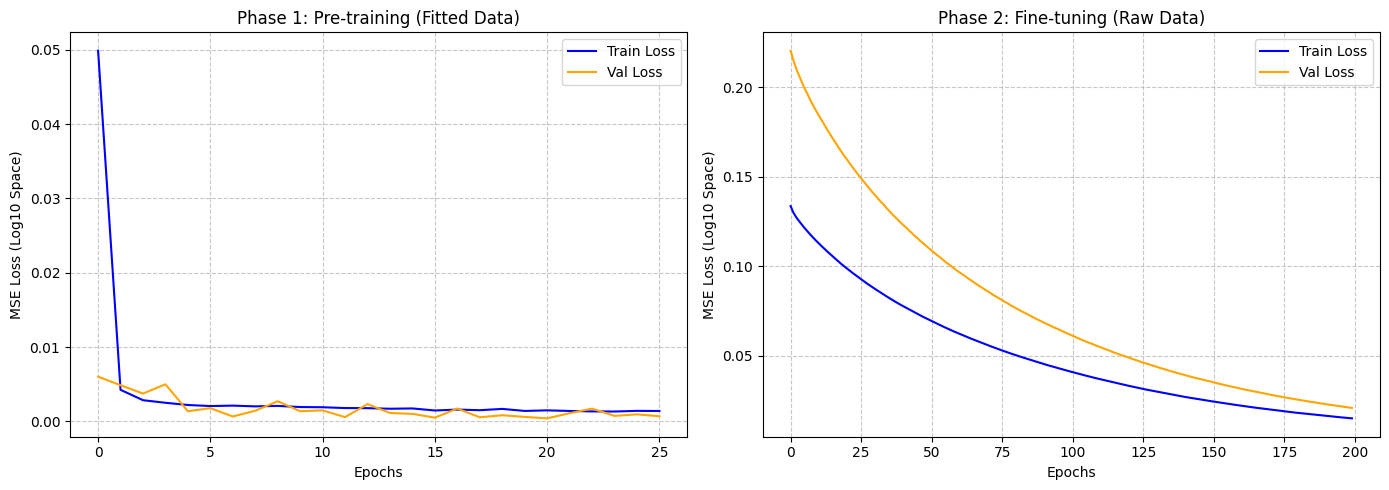

In [1]:
import joblib
import matplotlib.pyplot as plt

# Load the saved histories
history_fit = joblib.load('pretraining_history.joblib')
history_raw = joblib.load('fine_tuning_history.joblib')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Phase 1 (Fitted Data)
ax1.plot(history_fit['loss'], label='Train Loss', color='blue')
ax1.plot(history_fit['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Phase 1: Pre-training (Fitted Data)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss (Log10 Space)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Phase 2 (Raw Data)
ax2.plot(history_raw['loss'], label='Train Loss', color='blue')
ax2.plot(history_raw['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Phase 2: Fine-tuning (Raw Data)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MSE Loss (Log10 Space)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pickle

train_test_data = np.load('train_test_data.npz')
scalerXraw = pickle.load(open('scalerXraw.pkl', 'rb'))
scaleryraw = pickle.load(open('scaleryraw.pkl', 'rb'))
scalerXfit = pickle.load(open('scalerXfit.pkl', 'rb'))
scaleryfit = pickle.load(open('scaleryfit.pkl', 'rb'))

Xraw_selected_train = train_test_data['Xraw_selected_train']
Xraw_selected_train_scaled = scalerXraw.transform(Xraw_selected_train)  
Xraw_selected_test = train_test_data['Xraw_selected_test']
Xraw_selected_test_scaled = scalerXraw.transform(Xraw_selected_test)

yraw_selected_train = train_test_data['yraw_selected_train']
yraw_selected_train_scaled = scaleryraw.transform(yraw_selected_train.reshape(-1, 1))
yraw_selected_test = train_test_data['yraw_selected_test']
yraw_selected_test_scaled = scaleryraw.transform(yraw_selected_test.reshape(-1, 1))

Xfit_selected_train = train_test_data['Xfit_selected_train']
Xfit_selected_train_scaled = scalerXfit.transform(Xfit_selected_train)
Xfit_selected_test = train_test_data['Xfit_selected_test']
Xfit_selected_test_scaled = scalerXfit.transform(Xfit_selected_test)    

yfit_selected_train = train_test_data['yfit_selected_train']
yfit_selected_train_scaled = scaleryfit.transform(yfit_selected_train.reshape(-1, 1))
yfit_selected_test = train_test_data['yfit_selected_test']
yfit_selected_test_scaled = scaleryfit.transform(yfit_selected_test.reshape(-1, 1)) 

/home/redo/anaconda3/envs/lastpy/lib/python3.14/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Raw Min and Max j1 (Train): 0.0 16.0
Raw Min and Max j2 (Train): 0.0 23.0
Raw Min and Max j1  (Test): 0.0 16.0
Raw Min and Max j2  (Test): 0.0 23.0


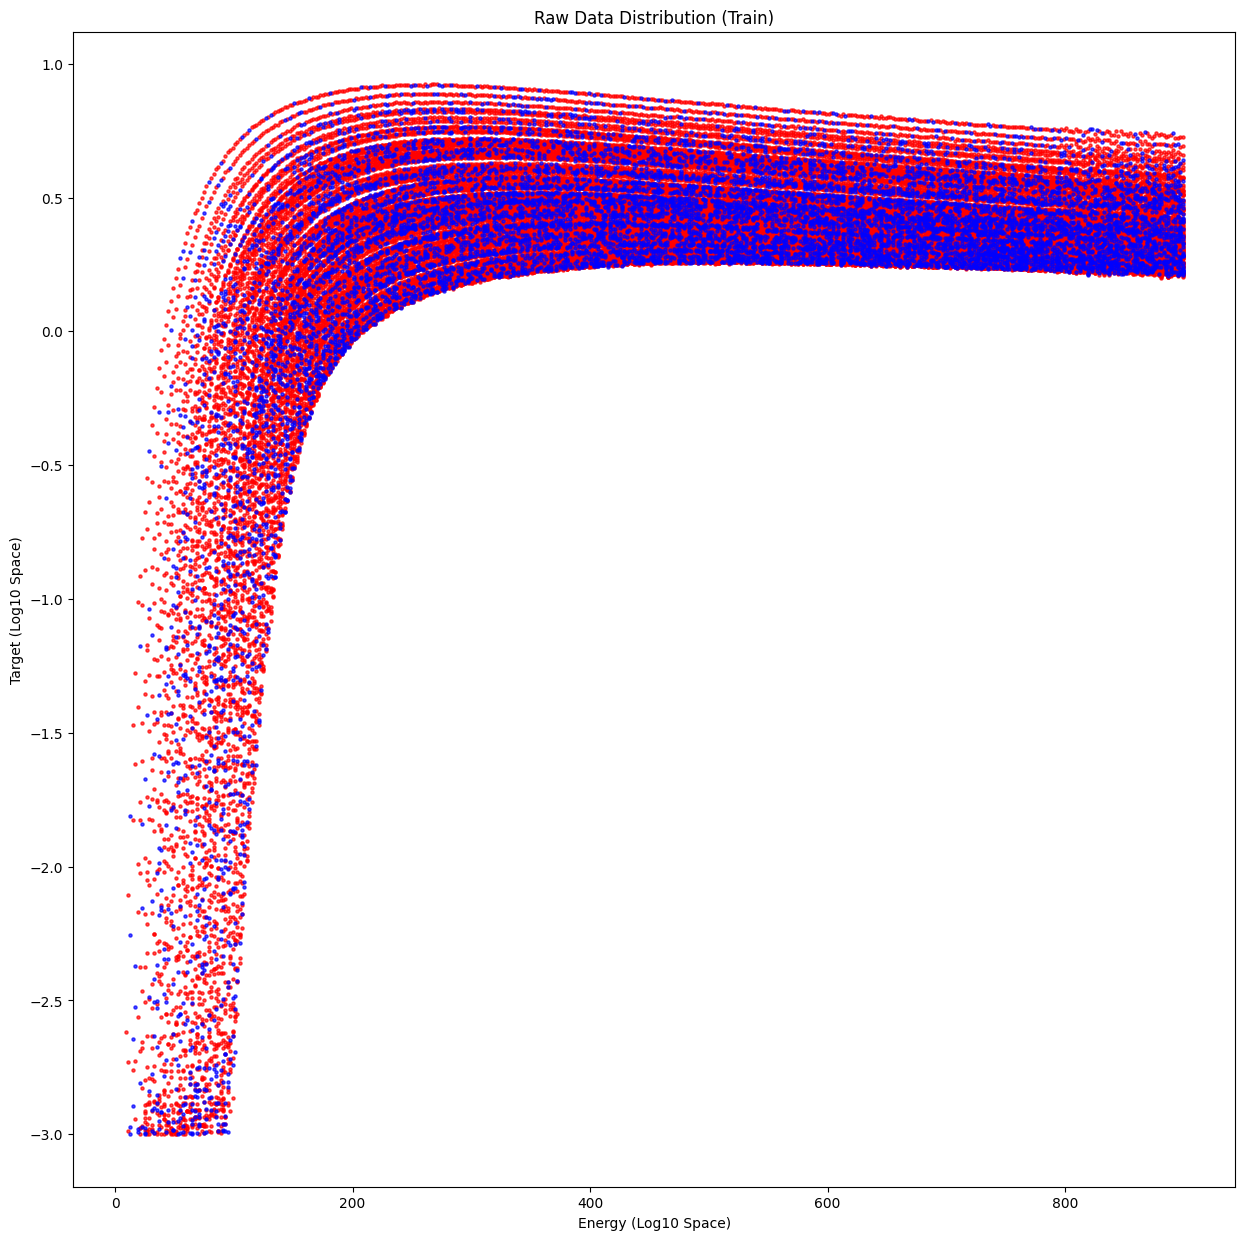

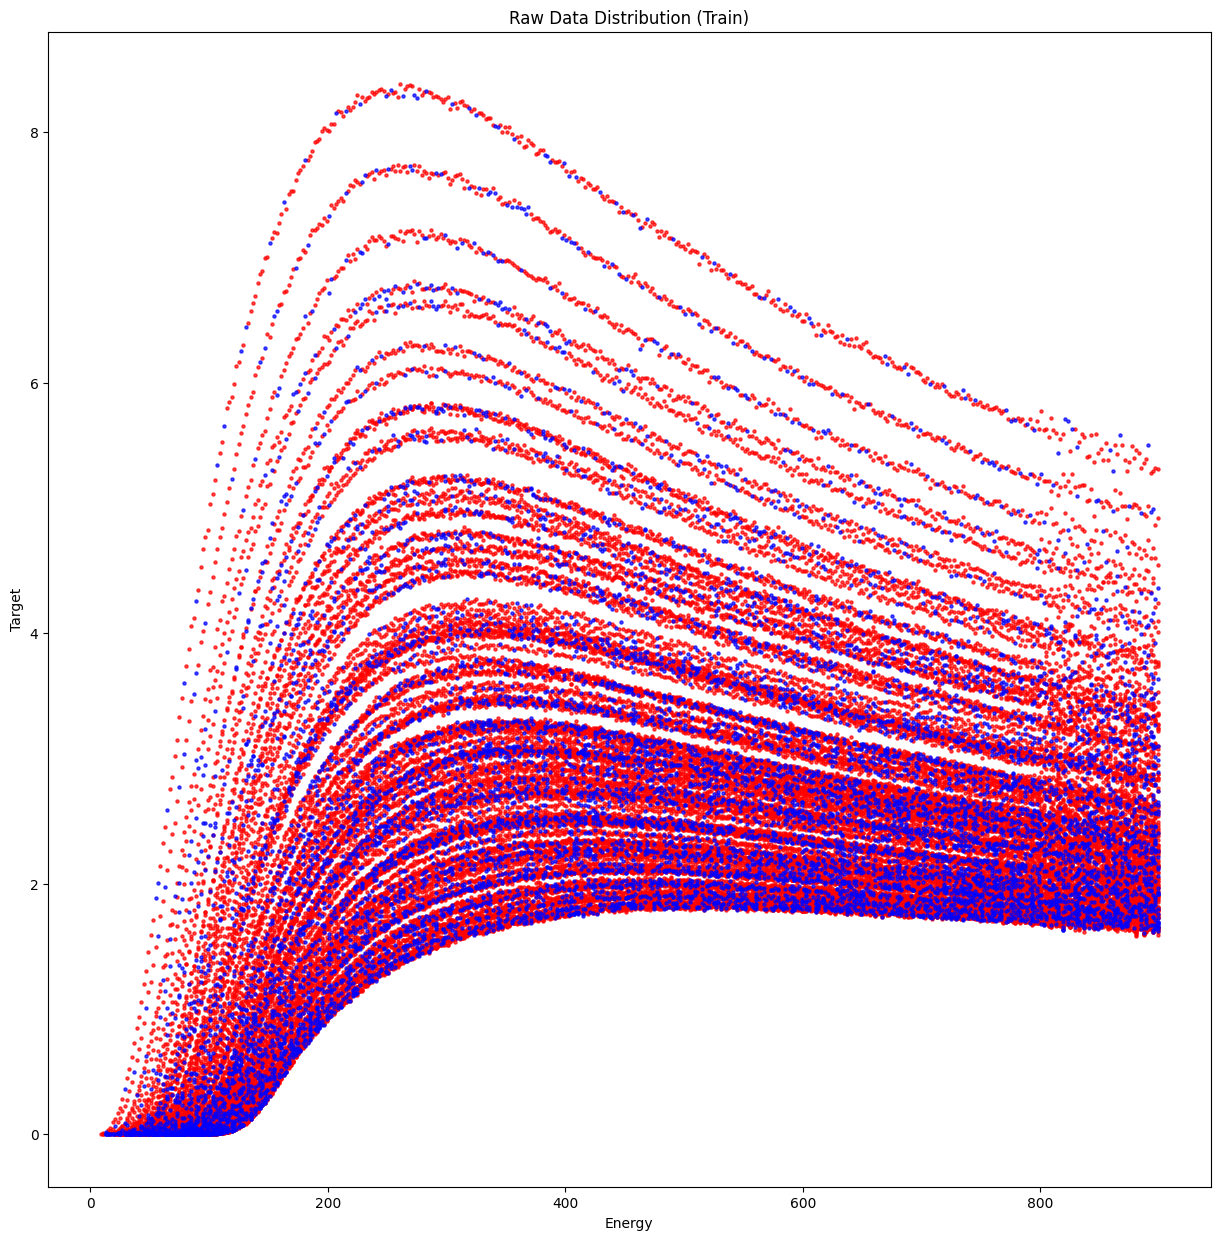

In [3]:
size=5
j1s_raw_train = Xraw_selected_train[:, 0]
j2s_raw_train = Xraw_selected_train[:, 1]
print("Raw Min and Max j1 (Train):", min(j1s_raw_train), max(j1s_raw_train))
print("Raw Min and Max j2 (Train):", min(j2s_raw_train), max(j2s_raw_train))
j1s_raw_test = Xraw_selected_test[:, 0]
j2s_raw_test = Xraw_selected_test[:, 1]
print("Raw Min and Max j1  (Test):", min(j1s_raw_test), max(j1s_raw_test))
print("Raw Min and Max j2  (Test):", min(j2s_raw_test), max(j2s_raw_test))   

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_train[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_test[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_train[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_test[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Raw Data Distribution (Train)')
plt.show()

Fitted Min and Max j1 (Train): 0.0 16.0
Fitted Min and Max j2 (Train): 0.0 23.0
Fitted Min and Max j1  (Test): 0.0 16.0
Fitted Min and Max j2  (Test): 0.0 23.0


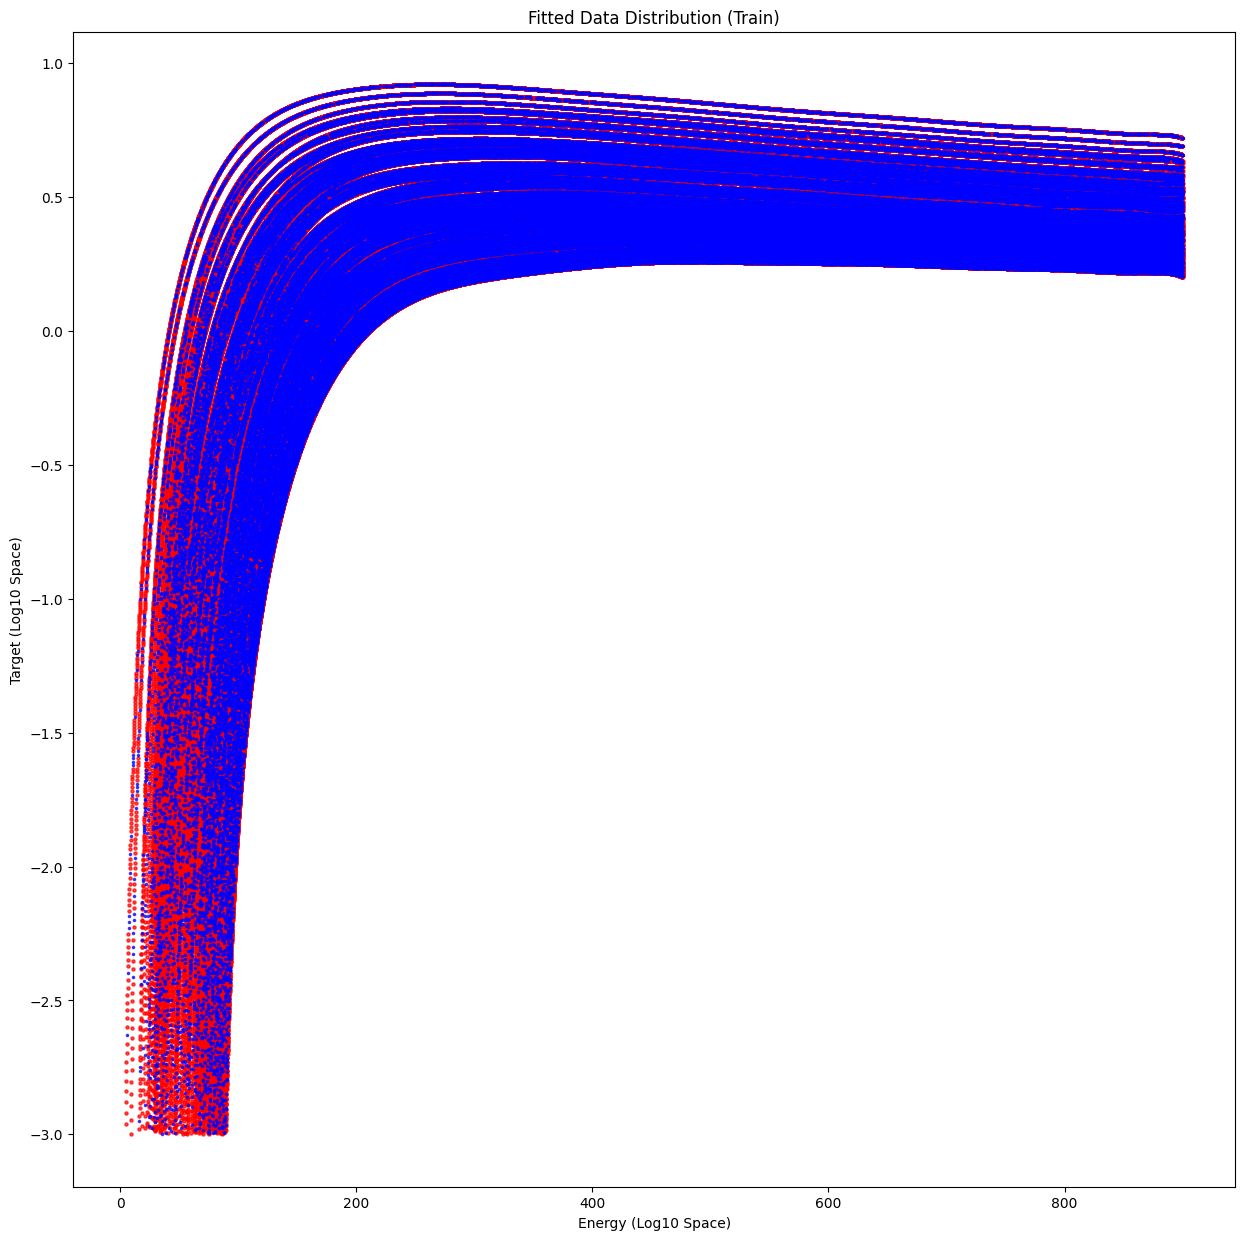

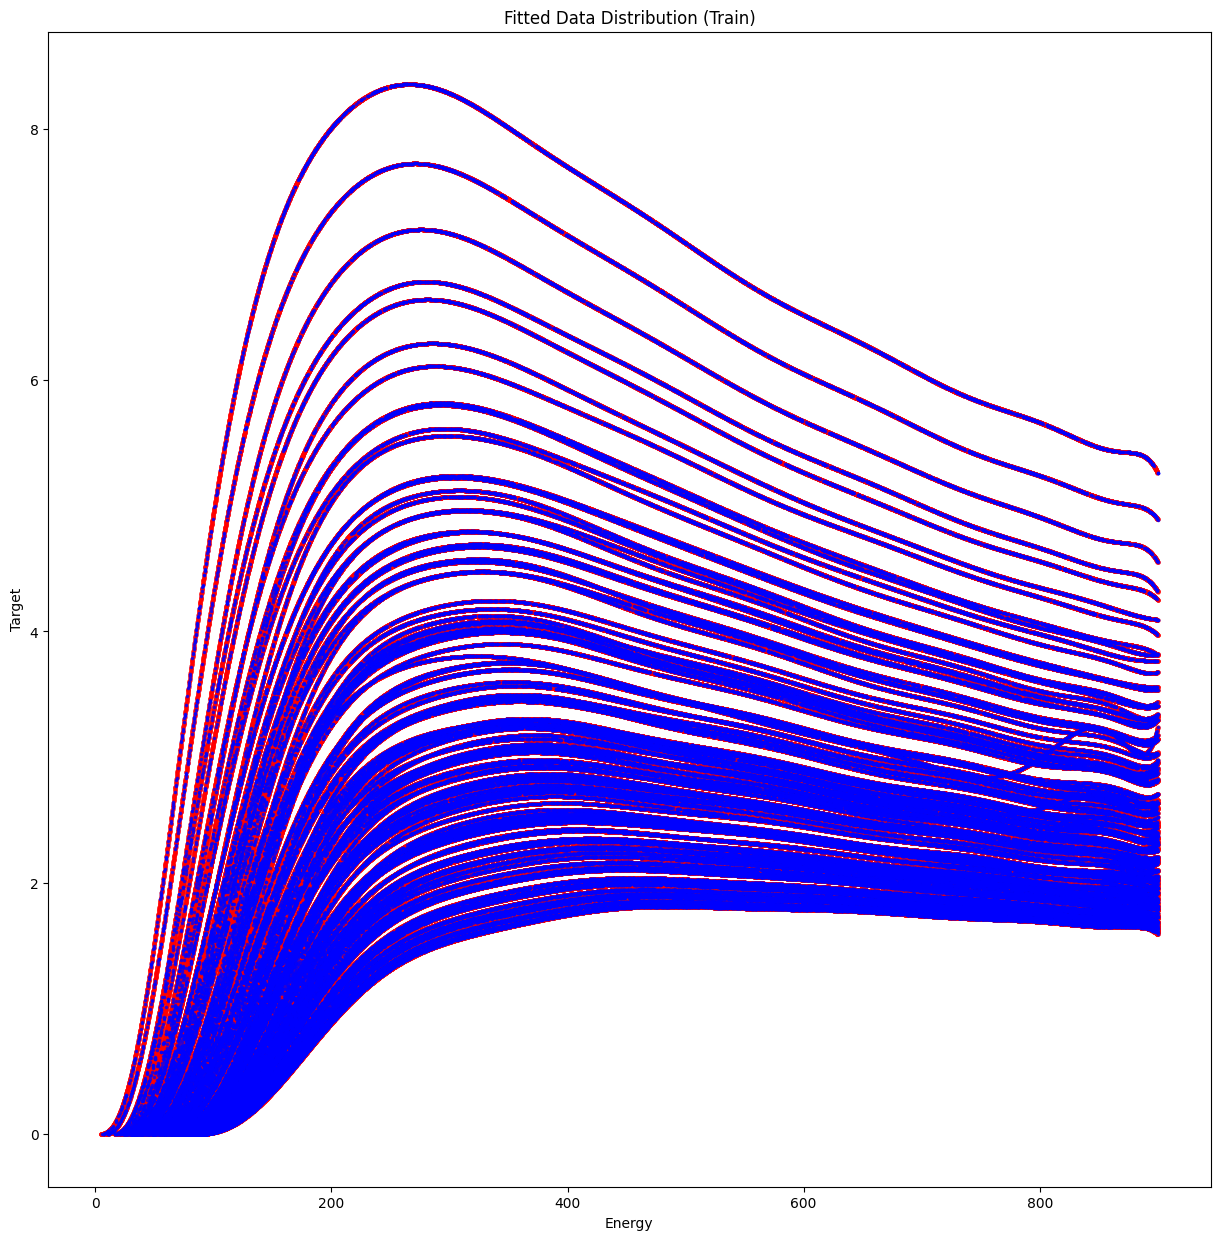

In [4]:
j1s_fit_train = Xfit_selected_train[:, 0]
j2s_fit_train = Xfit_selected_train[:, 1]
print("Fitted Min and Max j1 (Train):", min(j1s_fit_train), max(j1s_fit_train))
print("Fitted Min and Max j2 (Train):", min(j2s_fit_train), max(j2s_fit_train))
j1s_fit_test = Xfit_selected_test[:, 0]
j2s_fit_test = Xfit_selected_test[:, 1]
print("Fitted Min and Max j1  (Test):", min(j1s_fit_test), max(j1s_fit_test))
print("Fitted Min and Max j2  (Test):", min(j2s_fit_test), max(j2s_fit_test))

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_train[selectedindex]
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_test[selectedindex]
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')  
plt.title('Fitted Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_train[selectedindex])
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_test[selectedindex])
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Fitted Data Distribution (Train)')
plt.show()  

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pretrained_model= joblib.load('pretrained_model.joblib')
print("Pre-trained model loaded successfully.")
print("Pre-trained model summary:")
pretrained_model.summary()

pretrained_pred_scaled_test = pretrained_model.predict(Xraw_selected_test_scaled)
pretrained_pred_scaled_train = pretrained_model.predict(Xraw_selected_train_scaled)
pretrained_pred_test = scaleryraw.inverse_transform(\
    pretrained_pred_scaled_test.reshape(-1, 1))
pretrained_pred_train = scaleryraw.inverse_transform(\
    pretrained_pred_scaled_train.reshape(-1, 1))
pretrained_rmse_train = np.sqrt(np.mean((yraw_selected_train - pretrained_pred_train.flatten()) ** 2))
pretrained_rmse_test = np.sqrt(np.mean((yraw_selected_test - pretrained_pred_test.flatten()) ** 2))
pretrained_mae_train = np.mean(np.abs(yraw_selected_train - pretrained_pred_train.flatten()))
pretrained_mae_test = np.mean(np.abs(yraw_selected_test - pretrained_pred_test.flatten()))
pretrained_r2_train = 1 - np.sum((yraw_selected_train - pretrained_pred_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
pretrained_r2_test = 1 - np.sum((yraw_selected_test - pretrained_pred_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)

pretrained_pred_scaled_fit = pretrained_model.predict(Xfit_selected_test_scaled)
pretrained_pred_fit_test = scaleryfit.inverse_transform(pretrained_pred_scaled_fit.reshape(-1, 1))
pretrained_pred_scaled_train = pretrained_model.predict(Xfit_selected_train_scaled)
pretrained_pred_fit_train = scaleryfit.inverse_transform(pretrained_pred_scaled_train.reshape(-1,   1))
pretrained_rmse_train_fit = np.sqrt(np.mean((yfit_selected_train - pretrained_pred_fit_train.flatten()) ** 2))
pretrained_rmse_test_fit = np.sqrt(np.mean((yfit_selected_test - pretrained_pred_fit_test.flatten()) ** 2))
pretrained_mae_train_fit = np.mean(np.abs(yfit_selected_train - pretrained_pred_fit_train.flatten()))
pretrained_mae_test_fit = np.mean(np.abs(yfit_selected_test - pretrained_pred_fit_test.flatten()))
pretrained_r2_train_fit = 1 - np.sum((yfit_selected_train - pretrained_pred_fit_train.flatten()) ** 2) / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
pretrained_r2_test_fit = 1 - np.sum((yfit_selected_test - pretrained_pred_fit_test.flatten()) ** 2) / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)


I0000 00:00:1791193686.531276  313608 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791193686.552966  313608 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791193687.167012  313608 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Pre-trained model loaded successfully.
Pre-trained model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,445 (52.52 KB)

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,964 (35.02 KB)

343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step

I0000 00:00:1791193687.469147  314076 service.cc:154] XLA service 0x71f394030620 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791193687.469165  314076 service.cc:170]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1791193687.472670  314076 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791193687.507987  314076 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
6831/6831 ━━━━━━━━━━━━━━━━━━━━ 2s 296us/step
27322/27322 ━━━━━━━━━━━━━━━━━━━━ 8s 284us/step


In [6]:
fine_tuned_model = joblib.load('fine_tuned_model.joblib')
print("Fine-tuned model loaded successfully.")
print("Fine-tuned model summary:")
fine_tuned_model.summary()

fine_tuned_pred_scaled_test = fine_tuned_model.predict(Xraw_selected_test_scaled)
fine_tuned_pred_test = scaleryraw.inverse_transform(fine_tuned_pred_scaled_test.reshape(-1, 1))
fine_tuned_pred_scaled_train = fine_tuned_model.predict(Xraw_selected_train_scaled)
fine_tuned_pred_train = scaleryraw.inverse_transform(fine_tuned_pred_scaled_train.reshape(-1, 1))   
fine_tuned_rmse_train_ft = np.sqrt(np.mean((yraw_selected_train - fine_tuned_pred_train.flatten()) ** 2))
fine_tuned_rmse_test_ft = np.sqrt(np.mean((yraw_selected_test - fine_tuned_pred_test.flatten()) ** 2))
fine_tuned_mae_train_ft = np.mean(np.abs(yraw_selected_train - fine_tuned_pred_train.flatten()))
fine_tuned_mae_test_ft = np.mean(np.abs(yraw_selected_test - fine_tuned_pred_test.flatten()))
fine_tuned_r2_train_ft = 1 - np.sum((yraw_selected_train - fine_tuned_pred_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
fine_tuned_r2_test_ft = 1 - np.sum((yraw_selected_test - fine_tuned_pred_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)                                      

fine_tuned_pred_scaled_fit_test = fine_tuned_model.predict(Xfit_selected_test_scaled)
fine_tuned_pred_fit_test = scaleryfit.inverse_transform(fine_tuned_pred_scaled_fit_test.reshape(-1, 1))
fine_tuned_pred_scaled_fit_train = fine_tuned_model.predict(Xfit_selected_train_scaled)
fine_tuned_pred_fit_train = scaleryfit.inverse_transform(fine_tuned_pred_scaled_fit_train.reshape(-1, 1))
fine_tuned_rmse_train_fit_ft = np.sqrt(np.mean((yfit_selected_train - fine_tuned_pred_fit_train.flatten()) ** 2))
fine_tuned_rmse_test_fit_ft = np.sqrt(np.mean((yfit_selected_test - fine_tuned_pred_fit_test.flatten()) ** 2))
fine_tuned_mae_train_fit_ft = np.mean(np.abs(yfit_selected_train - fine_tuned_pred_fit_train.flatten()))
fine_tuned_mae_test_fit_ft = np.mean(np.abs(yfit_selected_test - fine_tuned_pred_fit_test.flatten()))
fine_tuned_r2_train_fit_ft = 1 - np.sum((yfit_selected_train - fine_tuned_pred_fit_train.flatten()) ** 2) / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
fine_tuned_r2_test_fit_ft = 1 - np.sum((yfit_selected_test - fine_tuned_pred_fit_test.flatten()) ** 2) / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)


Fine-tuned model loaded successfully.
Fine-tuned model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,613 (18.02 KB)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 4,416 (17.25 KB)

 Optimizer params: 132 (532.00 B)

343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step
6831/6831 ━━━━━━━━━━━━━━━━━━━━ 2s 301us/step
27322/27322 ━━━━━━━━━━━━━━━━━━━━ 8s 294us/step


In [7]:
print("Model Performance on Raw Data:")
print(f"Pretrained Train RMSE: {pretrained_rmse_train:.4f}, Test RMSE: {pretrained_rmse_test:.4f}")
print(f"Fine Tuned Train RMSE: {fine_tuned_rmse_train_ft:.4f}, Test RMSE: {fine_tuned_rmse_test_ft:.4f}")
print(f" Pretrained Train MAE: {pretrained_mae_train:.4f},  Test MAE: {pretrained_mae_test:.4f}")
print(f" Fine Tuned Train MAE: {fine_tuned_mae_train_ft:.4f},  Test MAE: {fine_tuned_mae_test_ft:.4f}")
print(f"  Pretrained Train R2: {pretrained_r2_train:.4f},   Test R2: {pretrained_r2_test:.4f}")
print(f"  Fine Tuned Train R2: {fine_tuned_r2_train_ft:.4f},   Test R2: {fine_tuned_r2_test_ft:.4f}")

print("Model Performance on Fitted Data:")
print(f"Pretrained Train RMSE: {pretrained_rmse_train_fit:.4f}, Test RMSE: {pretrained_rmse_test_fit:.4f}")
print(f"Fine Tuned Train RMSE: {fine_tuned_rmse_train_fit_ft:.4f}, Test RMSE: {fine_tuned_rmse_test_fit_ft:.4f}")
print(f" Pretrained Train MAE: {pretrained_mae_train_fit:.4f},  Test MAE: {pretrained_mae_test_fit:.4f}")
print(f" Fine Tuned Train MAE: {fine_tuned_mae_train_fit_ft:.4f},  Test MAE: {fine_tuned_mae_test_fit_ft:.4f}")
print(f"  Pretrained Train R2: {pretrained_r2_train_fit:.4f},   Test R2: {pretrained_r2_test_fit:.4f}")
print(f"  Fine Tuned Train R2: {fine_tuned_r2_train_fit_ft:.4f},   Test R2: {fine_tuned_r2_test_fit_ft:.4f}")   

Model Performance on Raw Data:
Pretrained Train RMSE: 0.1944, Test RMSE: 0.2516
Fine Tuned Train RMSE: 0.0637, Test RMSE: 0.0754
 Pretrained Train MAE: 0.0382,  Test MAE: 0.0448
 Fine Tuned Train MAE: 0.0192,  Test MAE: 0.0210
  Pretrained Train R2: 0.8618,   Test R2: 0.8017
  Fine Tuned Train R2: 0.9852,   Test R2: 0.9822
Model Performance on Fitted Data:
Pretrained Train RMSE: 0.0090, Test RMSE: 0.0089
Fine Tuned Train RMSE: 0.0583, Test RMSE: 0.0583
 Pretrained Train MAE: 0.0043,  Test MAE: 0.0044
 Fine Tuned Train MAE: 0.0310,  Test MAE: 0.0311
  Pretrained Train R2: 0.9996,   Test R2: 0.9996
  Fine Tuned Train R2: 0.9824,   Test R2: 0.9825


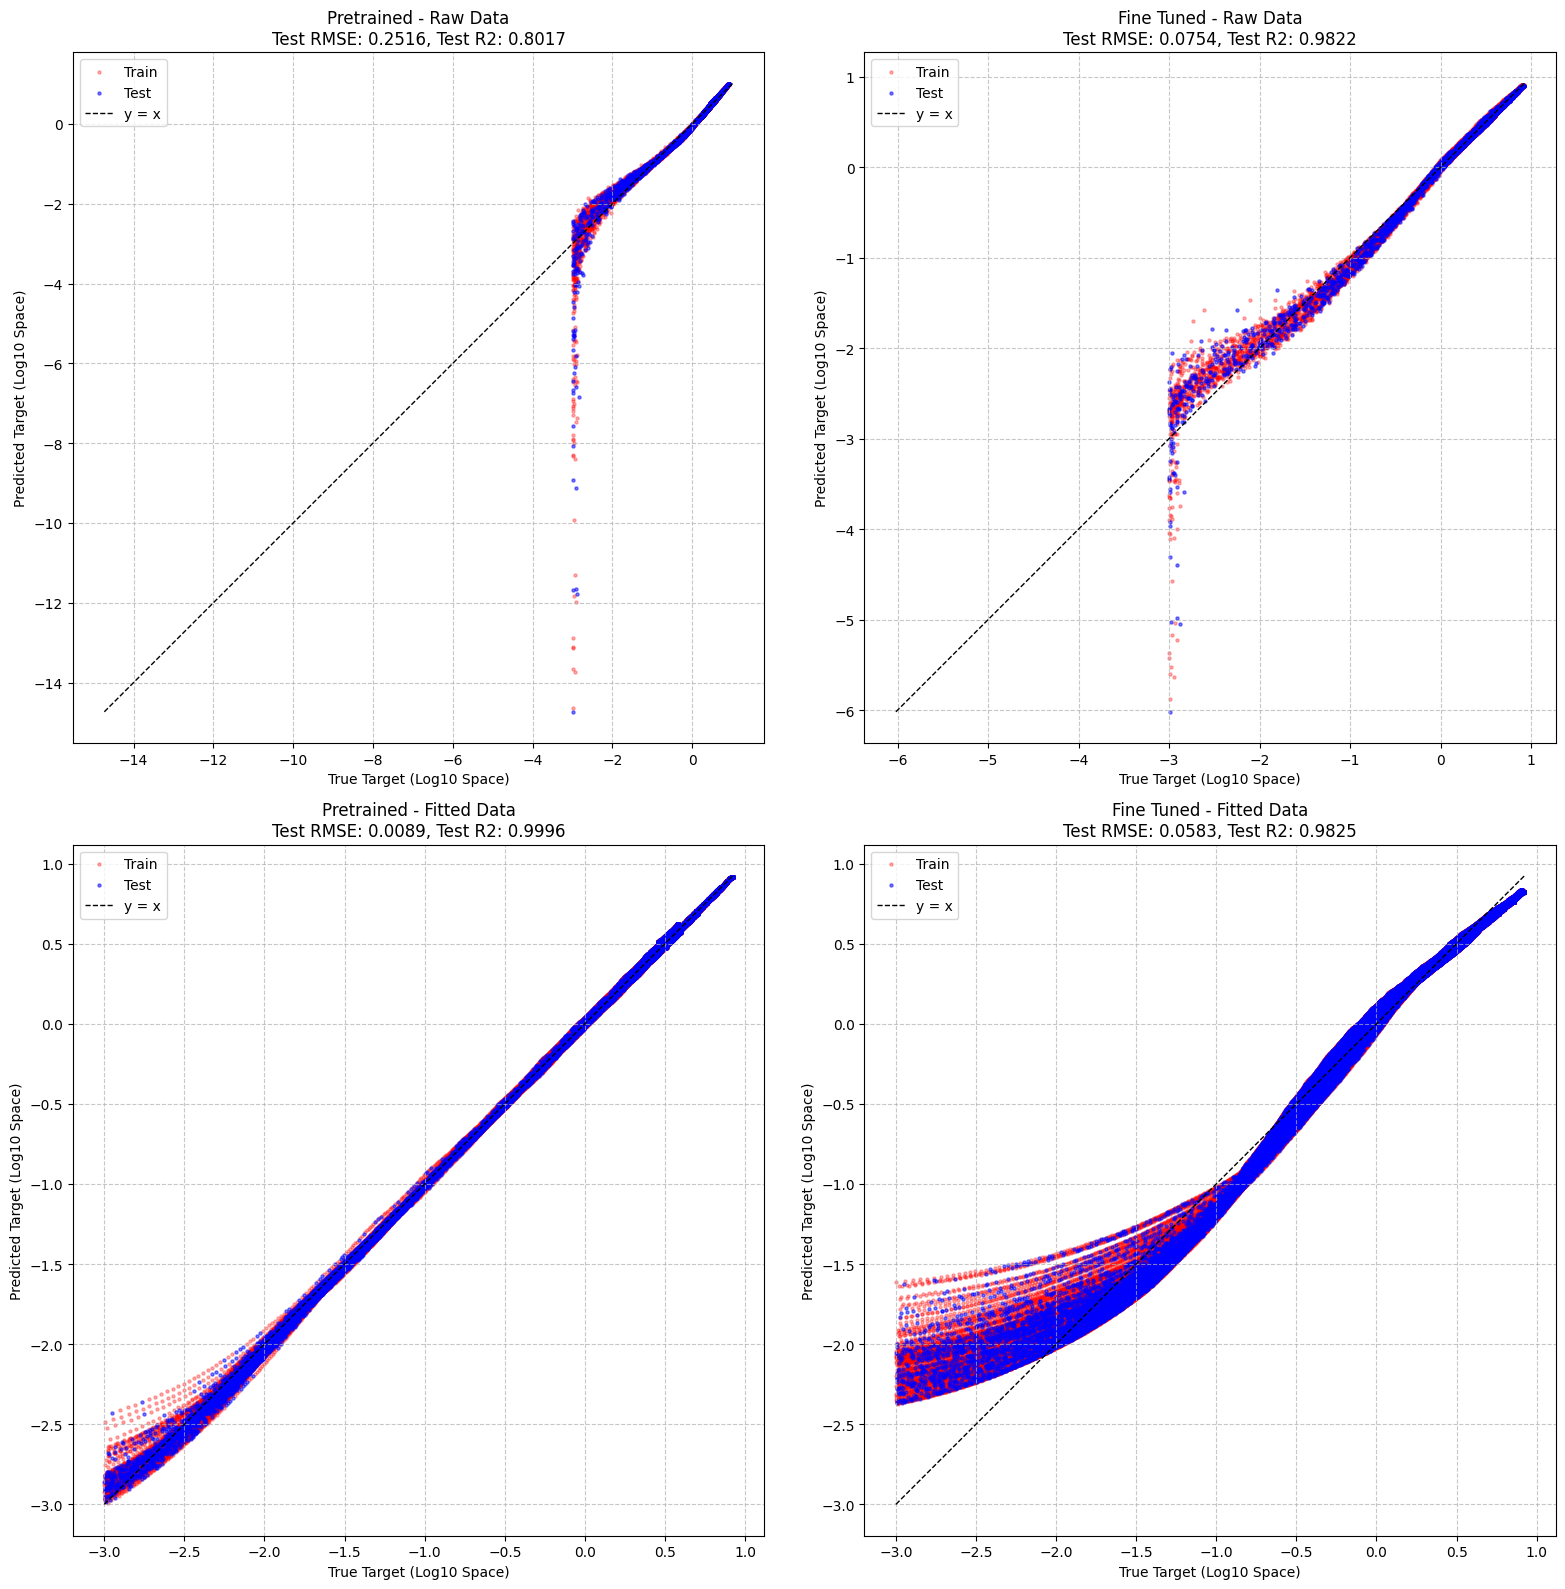

In [8]:
# Parity plots: predicted vs true (log10 space), pretrained vs fine-tuned model
def parity_panel(ax, y_train, p_train, y_test, p_test, title):
    p_train = p_train.flatten()
    p_test = p_test.flatten()
    ax.scatter(y_train, p_train, s=size, color='red', alpha=0.3, label='Train')
    ax.scatter(y_test, p_test, s=size, color='blue', alpha=0.5, label='Test')
    lo = min(y_train.min(), y_test.min(), p_train.min(), p_test.min())
    hi = max(y_train.max(), y_test.max(), p_train.max(), p_test.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')
    rmse = np.sqrt(np.mean((y_test - p_test) ** 2))
    r2 = r2_score(y_test, p_test)
    ax.set_title(f"{title}\nTest RMSE: {rmse:.4f}, Test R2: {r2:.4f}")
    ax.set_xlabel('True Target (Log10 Space)')
    ax.set_ylabel('Predicted Target (Log10 Space)')
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
parity_panel(axes[0, 0], yraw_selected_train, pretrained_pred_train,
             yraw_selected_test, pretrained_pred_test, 'Pretrained - Raw Data')
parity_panel(axes[0, 1], yraw_selected_train, fine_tuned_pred_train,
             yraw_selected_test, fine_tuned_pred_test, 'Fine Tuned - Raw Data')
parity_panel(axes[1, 0], yfit_selected_train, pretrained_pred_fit_train,
             yfit_selected_test, pretrained_pred_fit_test, 'Pretrained - Fitted Data')
parity_panel(axes[1, 1], yfit_selected_train, fine_tuned_pred_fit_train,
             yfit_selected_test, fine_tuned_pred_fit_test, 'Fine Tuned - Fitted Data')
plt.tight_layout()
plt.show()


Unique j1 values in raw train data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j1 values in raw  test data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j2 values in raw train data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
Unique j2 values in raw  test data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
Unique j1 values in raw data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j2 values in raw data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


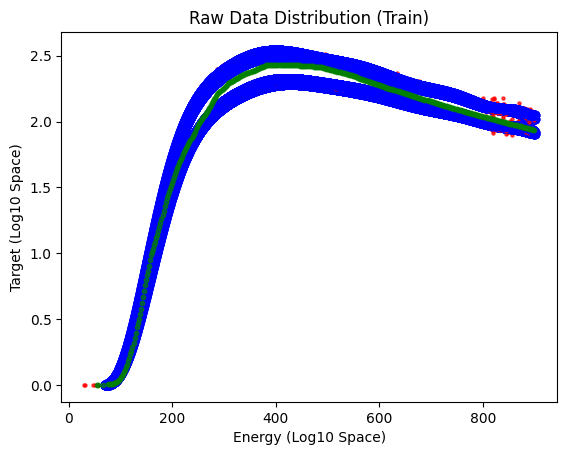

In [9]:

print("Unique j1 values in raw train data:", np.unique(Xraw_selected_train[:, 0]))
print("Unique j1 values in raw  test data:", np.unique(Xraw_selected_test[:, 0]))
print("Unique j2 values in raw train data:", np.unique(Xraw_selected_train[:, 1]))
print("Unique j2 values in raw  test data:", np.unique(Xraw_selected_test[:, 1]))

Xraw = np.concatenate((Xraw_selected_train, Xraw_selected_test), axis=0)
yraw = np.concatenate((yraw_selected_train, yraw_selected_test), axis=0)
Xfit = np.concatenate((Xfit_selected_train, Xfit_selected_test), axis=0)
yfit = np.concatenate((yfit_selected_train, yfit_selected_test), axis=0)

print("Unique j1 values in raw data:", np.unique(Xraw[:, 0]))
print("Unique j2 values in raw data:", np.unique(Xraw[:, 1]))

j1s= [1, 3]
j1pred = 2
j2s = [11, 13]
j2pred = 12
selectedindex = np.where((Xraw[:, 0] == j1s[0]) \
                         & (Xraw[:, 1] == j2s[0]))
Xraw_subset = Xraw[selectedindex]
evalues = Xraw_subset[:, 2]

X_pres = np.array([[j1pred, j2pred, e] for e in evalues])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
#print(f"Predictions for (v={j1pred}, j={j2pred}) at different energies:")
#for e, pred in zip(evalues, predictions.flatten()):
#    print(f"Energy: {e:.2f}, Predicted Target: {pred:.4f}")

for j1 in j1s:
    for j2 in j2s:
        selectedindex = np.where((Xraw[:, 0] == j1) & (Xraw[:, 1] == j2))
        Xraw_subset = Xraw[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw[selectedindex]
        yraw_subset = np.pow(10, yraw_subset)
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
        selectedindex = np.where((Xfit[:, 0] == j1) & (Xfit[:, 1] == j2))
        Xfit_subset = Xfit[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit[selectedindex]
        yfit_subset = np.pow(10, yfit_subset)
        plt.scatter(efit, yfit_subset, linewidths=1, label="Train (Fitted)", color='blue', alpha=0.7) 
plt.scatter(evalues, np.pow(10, predictions.flatten()), s=size*2, label="Predictions (v=10,j=2)+(v=0,j=30)", color='green', alpha=0.7)  
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step


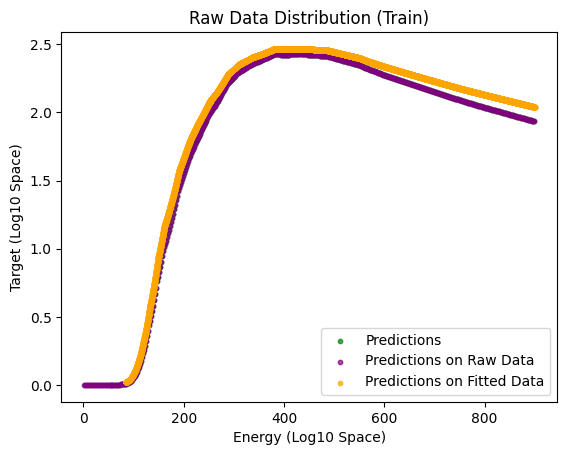

In [ ]:
evaluesraw = np.load('evaluesraw.npz')['evalues']
evaluesfit = np.load('evaluesfit.npz')['evalues']

X_pres = np.array([[j1pred, j2pred, e] for e in evalues])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
X_pres = np.array([[j1pred, j2pred, e] for e in evaluesraw])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions_raw = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
X_pres = np.array([[j1pred, j2pred, e] for e in evaluesfit])
X_pres_scaled = scalerXfit.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions_fit = scaleryfit.inverse_transform(predictions_scaled.reshape(-1, 1))

plt.scatter(evalues, np.pow(10, predictions.flatten()), s=size*2, label="Predictions", color='green', alpha=0.7)  
plt.scatter(evaluesraw, np.pow(10, predictions_raw.flatten()), s=size*2, label="Predictions on Raw Data", color='purple', alpha=0.7)
plt.scatter(evaluesfit, np.pow(10, predictions_fit.flatten()), s=size*2, label="Predictions on Fitted Data", color='orange', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.legend()
plt.show()
